# 01 — Exploratory Data Analysis

Looks at the traffic signal before any modeling: how traffic is distributed across all 10,000 squares, how the 5 target squares behave over time, and the autocorrelation/stationarity of the busiest one. These findings shape the modeling choices in `02_sarima.ipynb` and `03_lstm_tcn.ipynb`.

Run `00_data_pipeline.ipynb` first — this reads its output files.


In [1]:
import os
import sys

if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")
sys.path.insert(0, ".")

import matplotlib.pyplot as plt
import pandas as pd
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import adfuller

import common
from common import OBSERVATION_START, SQUARE_TOTALS_PATH

os.makedirs("figures", exist_ok=True)
os.makedirs("results", exist_ok=True)

meta = common.load_target_squares_meta()
totals = pd.read_csv(SQUARE_TOTALS_PATH, index_col="square_id")["internet_total"]
print("Top-3 squares by total internet traffic:", meta["top3_totals"])
print("Fixed squares (assignment brief):", meta["fixed_squares"])

Top-3 squares by total internet traffic: {5059: 11091868.9296875, 5161: 12682672.830078125, 5259: 10436792.0703125}
Fixed squares (assignment brief): [4159, 4556]


## 1. Distribution of total traffic across all 10,000 squares

If traffic were roughly uniform across the city, one "representative" square would be enough. If it's concentrated in a few hubs, that's where the model comparison should focus — which is what picking the top-3 by traffic is for.


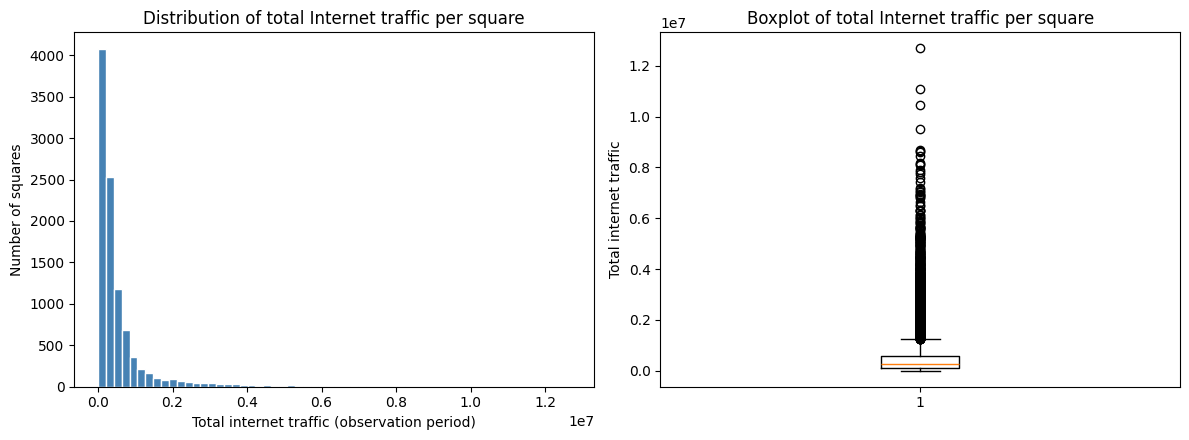

{'n_squares': 10000,
 'mean': 549972.8327479402,
 'median': 274706.2022705078,
 'std': 886213.1925597443,
 'min': 213.6265325546265,
 'max': 12682672.830078123,
 'skewness': 4.278303283574248,
 'kurtosis': 25.67026797561807,
 'p90': 1231417.6806640625,
 'p99': 4666201.690566409,
 'share_top_1pct_of_total': 0.1108597436067262}

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].hist(totals.values, bins=60, color="steelblue", edgecolor="white")
axes[0].set_title("Distribution of total Internet traffic per square")
axes[0].set_xlabel("Total internet traffic (observation period)")
axes[0].set_ylabel("Number of squares")

axes[1].boxplot(totals.values, vert=True)
axes[1].set_title("Boxplot of total Internet traffic per square")
axes[1].set_ylabel("Total internet traffic")
fig.tight_layout()
fig.savefig("figures/eda_traffic_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

dist_stats = {
    "n_squares": int(totals.shape[0]),
    "mean": float(totals.mean()),
    "median": float(totals.median()),
    "std": float(totals.std()),
    "min": float(totals.min()),
    "max": float(totals.max()),
    "skewness": float(totals.skew()),
    "kurtosis": float(totals.kurtosis()),
    "p90": float(totals.quantile(0.90)),
    "p99": float(totals.quantile(0.99)),
    "share_top_1pct_of_total": float(totals.sort_values(ascending=False).head(int(len(totals) * 0.01)).sum() / totals.sum()),
}
pd.DataFrame([dist_stats]).to_csv("results/data_summary.csv", index=False)
dist_stats

Traffic is heavily right-skewed (skewness ≈ 4.28, mean ≈ 549,973 vs. median ≈ 274,706 — the mean is roughly double). The top 1% of squares (100 of 10,000) account for ~11.1% of all traffic. That matches what you'd expect in a city: a handful of business/transit hubs carry most of the load. Worth focusing modeling effort on the top-3 squares — they're the ones an operator would actually need to forecast well.


## 2. First two weeks: top-3 squares + the two brief-required squares

Comparing the top-3 squares against the two the brief requires (4159, 4556) — does "high traffic" mean a different shape of traffic, or just the same daily pattern scaled up?


Plotting first-two-weeks series for squares: [4159, 4556, 5059, 5161, 5259]


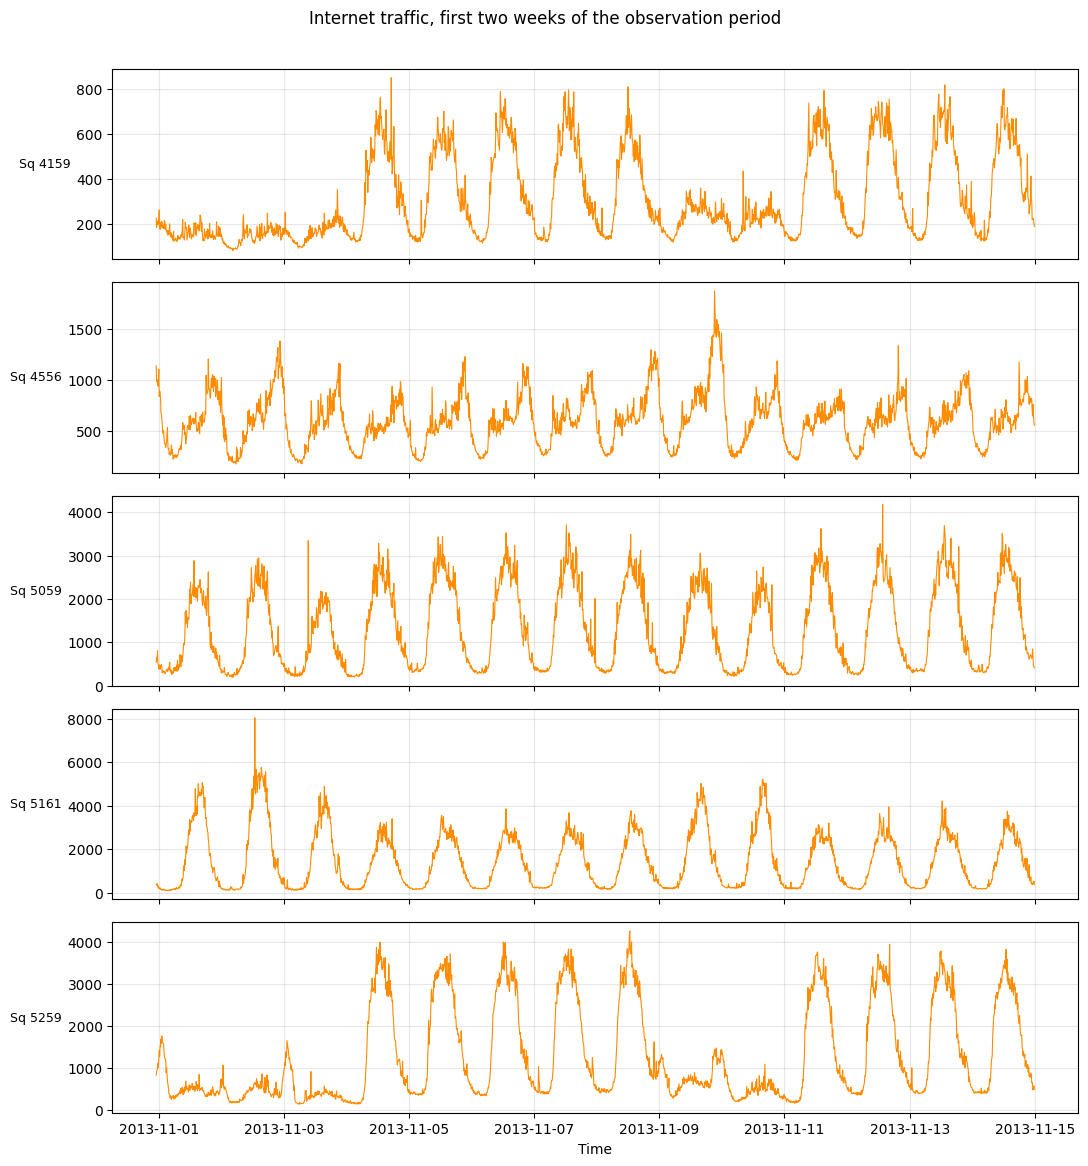

In [3]:
five_squares = sorted(set(meta["top3_squares"]) | set(meta["fixed_squares"]))
two_weeks_end = pd.Timestamp(OBSERVATION_START) + pd.Timedelta(days=14)
print("Plotting first-two-weeks series for squares:", five_squares)

fig, axes = plt.subplots(len(five_squares), 1, figsize=(11, 2.3 * len(five_squares)), sharex=True)
for ax, sq in zip(axes, five_squares):
    s = common.load_square_series(sq)
    s = s[s.index < two_weeks_end]
    ax.plot(s.index, s.values, linewidth=0.8, color="darkorange")
    ax.set_ylabel(f"Sq {sq}", rotation=0, ha="right", va="center", fontsize=9)
    ax.grid(alpha=0.3)
axes[-1].set_xlabel("Time")
fig.suptitle("Internet traffic, first two weeks of the observation period", y=1.01)
fig.tight_layout()
fig.savefig("figures/eda_five_squares_first_two_weeks.png", dpi=150, bbox_inches="tight")
plt.show()

All five squares show the same daily commuting rhythm — a trough around 4-6am, a broad daytime peak — but differ in scale and shape:
- **4159**: strongest weekday/weekend contrast, flatter on weekends. Looks like a business area.
- **4556**: noisier, higher overnight baseline. More residential/mixed-use.
- **5059, 5161, 5259** (top-3): biggest peaks, move together in time — probably adjacent, dense squares. **5161** also has two big one-off spikes (Nov 3 and 10, both Sundays), 2-3x its usual Sunday peak. Worth flagging — a model trained on "typical" days will likely miss these (comes back as a failure case in `04_model_comparison.ipynb`).


## 3. Autocorrelation, seasonality, and stationarity of the top-traffic square

Three checks that feed straight into modeling decisions: ACF/PACF for SARIMA's order and the LSTM/TCN sequence length, STL for whether seasonality needs to be modeled explicitly, ADF for whether differencing is needed.


Running ACF/PACF + STL decomposition + ADF test on top square 5161


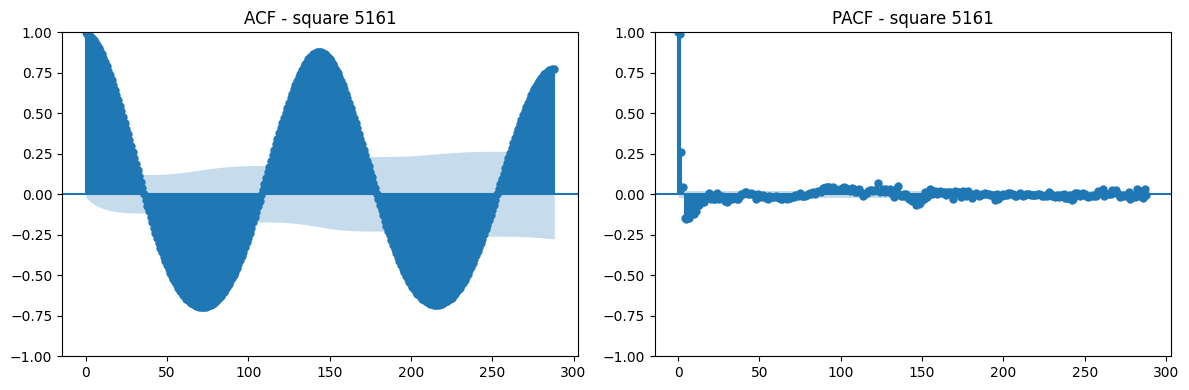

In [4]:
top_square = meta["top3_squares"][0]
s = common.load_square_series(top_square)
print(f"Running ACF/PACF + STL decomposition + ADF test on top square {top_square}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_acf(s, lags=288, ax=axes[0])
axes[0].set_title(f"ACF - square {top_square}")
plot_pacf(s, lags=288, ax=axes[1], method="ywm")
axes[1].set_title(f"PACF - square {top_square}")
fig.tight_layout()
fig.savefig("figures/eda_acf_pacf_top1.png", dpi=150, bbox_inches="tight")
plt.show()

The ACF has clear peaks at lag ≈144 and ≈288 (1 and 2 days) — strong daily seasonality, nothing shorter going on. The PACF cuts off after 1-2 lags, so once you account for the daily cycle, there's not much short-term structure left. That means: keep SARIMA's AR order low and let the seasonal term do the work, and give LSTM/TCN at least 144 steps of input so they can see a full day.


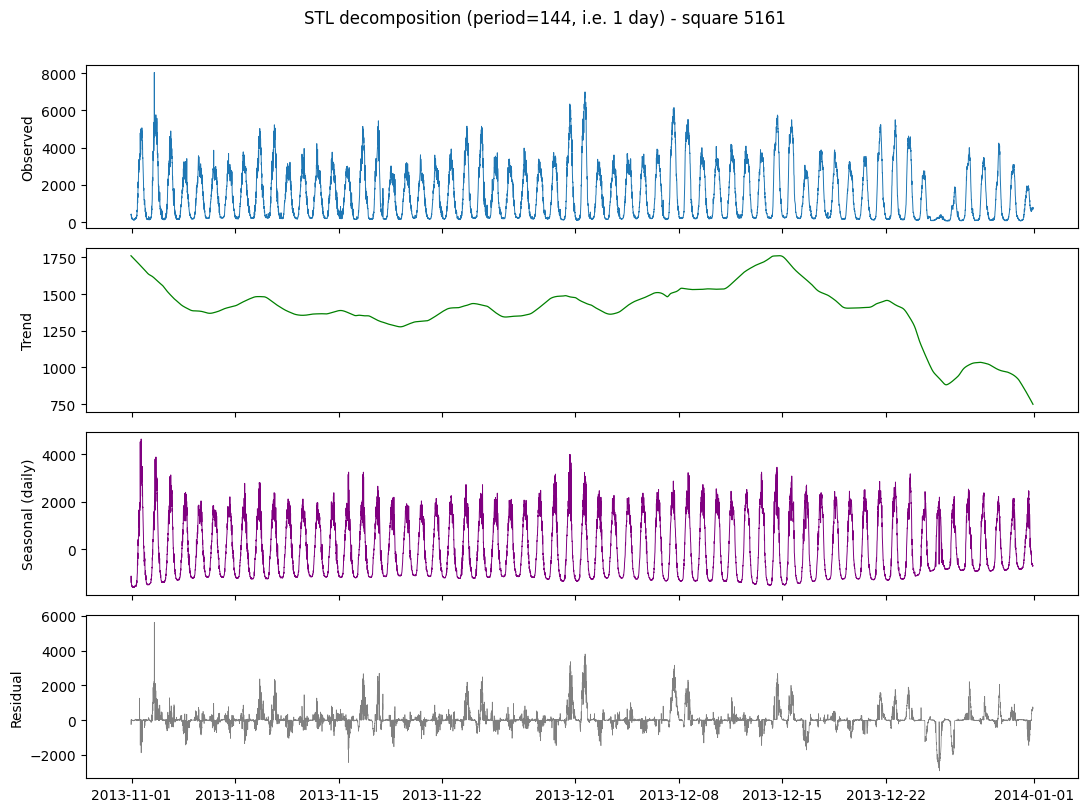

,series,adf_stat,p_value,n_lags_used,critical_5pct,stationary_at_5pct
0,level,-19.130738,0.000000e+00,36,-2.861870,True
1,first_difference,-15.054898,9.180269e-28,37,-2.861871,True


In [5]:
stl = STL(s, period=144, robust=True).fit()
fig, axes = plt.subplots(4, 1, figsize=(11, 8), sharex=True)
axes[0].plot(s.index, s.values, linewidth=0.7); axes[0].set_ylabel("Observed")
axes[1].plot(s.index, stl.trend, linewidth=0.9, color="green"); axes[1].set_ylabel("Trend")
axes[2].plot(s.index, stl.seasonal, linewidth=0.7, color="purple"); axes[2].set_ylabel("Seasonal (daily)")
axes[3].plot(s.index, stl.resid, linewidth=0.5, color="gray"); axes[3].set_ylabel("Residual")
fig.suptitle(f"STL decomposition (period=144, i.e. 1 day) - square {top_square}", y=1.01)
fig.tight_layout()
fig.savefig("figures/eda_stl_decomposition_top1.png", dpi=150, bbox_inches="tight")
plt.show()

adf_level = adfuller(s.dropna(), autolag="AIC")
adf_diff = adfuller(s.diff().dropna(), autolag="AIC")
stationarity_df = pd.DataFrame([
    {"series": "level", "adf_stat": adf_level[0], "p_value": adf_level[1],
     "n_lags_used": adf_level[2], "critical_5pct": adf_level[4]["5%"],
     "stationary_at_5pct": adf_level[1] < 0.05},
    {"series": "first_difference", "adf_stat": adf_diff[0], "p_value": adf_diff[1],
     "n_lags_used": adf_diff[2], "critical_5pct": adf_diff[4]["5%"],
     "stationary_at_5pct": adf_diff[1] < 0.05},
])
stationarity_df.to_csv("results/stationarity_tests.csv", index=False)
stationarity_df

STL confirms a strong, stable daily component and a slow-moving trend; residuals are small except around those anomalous spikes. The ADF test rejects the unit-root null on both the level (stat ≈ −19.13, p ≈ 0) and the first difference (stat ≈ −15.05, p ≈ 9.2×10⁻²⁸). That's a partial signal though — ADF only checks for a stochastic trend, not seasonality. So differencing isn't strictly needed, but the daily cycle still has to be modeled explicitly one way or another.

**What this means for modeling:**
| Finding | Consequence |
|---|---|
| Heavy right-skew, top-1% dominate | Focus on top-3 squares |
| Strong daily periodicity, low-order residuals | SARIMA: low `(p,d,q)` + Fourier terms |
| ACF/PACF cut off after 1-2 lags | LSTM/TCN: sequence length ≥ 144 |
| Stationary in level and diff | `d=1` is a safe default |
| Sharp spikes on square 5161 | Expected failure case later |
